# A Machine Learning and Nash Equilibrium Framework for PSA Screening Patterns in BRFSS 2022

## CONFIGURATION AND HELPER FUNCTIONS

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    brier_score_loss,
    classification_report
)

from sklearn.calibration import calibration_curve


# -----------------------------
# Global notebook options
# -----------------------------

VERBOSE = False       # Set True if you want detailed checks
SAVE_OUTPUTS = True  # Save clean tables and figures
SHOW_PLOTS = True    # Display plots in notebook

OUTPUT_DIR = "outputs"
FIGURE_DIR = "figures"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)


# -----------------------------
# Constants
# -----------------------------

INVALID_CODES = [7, 9, 77, 99, 777, 999]

YES_CODE = 1
NO_CODE = 2

MALE_CODE = 1
PROSTATE_CANCER_CODE = 20


# -----------------------------
# Display helpers
# -----------------------------

def log_section(title):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)


def log(message):
    if VERBOSE:
        print(message)


def display_table(df, title=None, max_rows=20, round_digits=4):
    if title is not None:
        print("\n" + title)
        print("-" * len(title))
    
    display(df.round(round_digits).head(max_rows))


def save_table(df, filename):
    if SAVE_OUTPUTS:
        path = os.path.join(OUTPUT_DIR, filename)
        df.to_csv(path, index=False)


def save_figure(filename):
    if SAVE_OUTPUTS:
        path = os.path.join(FIGURE_DIR, filename)
        plt.savefig(path, dpi=300, bbox_inches="tight")


def summarize_binary(series, label):
    valid = series.dropna()
    
    return {
        "Variable": label,
        "Valid N": int(valid.shape[0]),
        "Missing N": int(series.isna().sum()),
        "Positive N": int(valid.sum()) if valid.shape[0] > 0 else np.nan,
        "Negative N": int((valid == 0).sum()) if valid.shape[0] > 0 else np.nan,
        "Prevalence": valid.mean() if valid.shape[0] > 0 else np.nan
    }


def summarize_missingness(df, columns):
    out = (
        df[columns]
        .isna()
        .sum()
        .reset_index()
        .rename(columns={"index": "Variable", 0: "Missing N"})
    )
    
    out["Missing %"] = out["Missing N"] / len(df)
    
    return out.sort_values("Missing %", ascending=False)


## 1. LOAD BRFSS DATA

In [2]:
# ============================================================
# 1. LOAD BRFSS DATA
# ============================================================

def load_brfss_data(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    
    try:
        import pyreadstat
        
        df, meta = pyreadstat.read_xport(
            file_path,
            encoding="latin1",
            dates_as_pandas_datetime=True
        )
        
        return df, meta
    
    except Exception as e:
        print("pyreadstat failed. Trying pandas.read_sas...")
        print("Error:", e)
        
        df = pd.read_sas(
            file_path,
            format="xport",
            encoding="latin1"
        )
        
        return df, None


# Modify this path if needed
FILE_PATH = r"C:\Users\hp\Downloads\LLCP2022XPT\LLCP2022.XPT"

df, meta = load_brfss_data(FILE_PATH)

log_section("BRFSS 2022 Data Loaded")

data_summary = pd.DataFrame({
    "Item": [
        "Rows",
        "Columns",
        "First column",
        "Last column"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.columns[0],
        df.columns[-1]
    ]
})

display_table(data_summary, "Dataset summary")



BRFSS 2022 Data Loaded

Dataset summary
---------------


,Item,Value
0,Rows,445132
1,Columns,328
2,First column,_STATE
3,Last column,_AIDTST4


## 2. REQUIRED VARIABLE CHECK

In [3]:

required_cols = [
    "_SEX",
    "_AGE80",
    "_IMPRACE",
    "PSATEST1",
    "PSATIME1",
    "CNCRTYP2",
    "CHCOCNC1",
    "INCOME3",
    "_HLTHPLN",
    "EDUCA",
    "_BMI5",
    "PERSDOC3",
    "GENHLTH",
    "_LLCPWT"
]

variable_check = pd.DataFrame({
    "Variable": required_cols,
    "Status": ["Found" if col in df.columns else "Missing" for col in required_cols]
})

display_table(variable_check, "Required variable check")

missing_required = variable_check.loc[variable_check["Status"] == "Missing", "Variable"].tolist()

if len(missing_required) > 0:
    raise ValueError(f"Missing required variables: {missing_required}")


if VERBOSE:
    for col in required_cols:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False).sort_index())



Required variable check
-----------------------


,Variable,Status
0,_SEX,Found
1,_AGE80,Found
2,_IMPRACE,Found
3,PSATEST1,Found
4,PSATIME1,Found
5,CNCRTYP2,Found
6,CHCOCNC1,Found
7,INCOME3,Found
8,_HLTHPLN,Found
9,EDUCA,Found


## 3. ANALYTIC COHORT: MEN AGED 40--80 YEARS

In [4]:
df_base = df.copy()

df_base["_AGE80_clean"] = df_base["_AGE80"].replace(INVALID_CODES, np.nan)

men_40_80 = df_base[
    (df_base["_SEX"] == MALE_CODE) &
    (df_base["_AGE80_clean"] >= 40) &
    (df_base["_AGE80_clean"] <= 80)
].copy()

men_40_80["age"] = men_40_80["_AGE80_clean"]

cohort_summary_initial = pd.DataFrame({
    "Sample": [
        "Full BRFSS 2022",
        "Male respondents",
        "Men aged 40--80 years"
    ],
    "N": [
        len(df),
        int((df["_SEX"] == MALE_CODE).sum()),
        len(men_40_80)
    ]
})

display_table(cohort_summary_initial, "Initial analytic sample flow")


age_summary = pd.DataFrame({
    "Statistic": ["Mean", "SD", "Min", "Median", "Max"],
    "Age": [
        men_40_80["age"].mean(),
        men_40_80["age"].std(),
        men_40_80["age"].min(),
        men_40_80["age"].median(),
        men_40_80["age"].max()
    ]
})

display_table(age_summary, "Age summary among men aged 40--80")



Initial analytic sample flow
----------------------------


,Sample,N
0,Full BRFSS 2022,445132
1,Male respondents,209238
2,Men aged 40--80 years,152936



Age summary among men aged 40--80
---------------------------------


,Statistic,Age
0,Mean,61.796
1,SD,11.801
2,Min,40.000
3,Median,63.000
4,Max,80.000


## 4. CREATE OUTCOME VARIABLES

In [5]:
# ============================================================
# 4. CREATE OUTCOME VARIABLES
# ============================================================

df_model = men_40_80.copy()

# -----------------------------
# Clean raw variables
# -----------------------------

df_model["PSATEST1_clean"] = df_model["PSATEST1"].replace(INVALID_CODES, np.nan)
df_model["PSATIME1_clean"] = df_model["PSATIME1"].replace(INVALID_CODES, np.nan)
df_model["CHCOCNC1_clean"] = df_model["CHCOCNC1"].replace(INVALID_CODES, np.nan)
df_model["CNCRTYP2_clean"] = df_model["CNCRTYP2"].replace(INVALID_CODES, np.nan)


# -----------------------------
# Outcome 1: ever had PSA test
# -----------------------------

df_model["had_psa"] = np.nan

df_model.loc[df_model["PSATEST1_clean"] == YES_CODE, "had_psa"] = 1
df_model.loc[df_model["PSATEST1_clean"] == NO_CODE, "had_psa"] = 0


# -----------------------------
# Outcome 2: recent PSA within past 2 years
# -----------------------------

df_model["recent_psa_2y"] = np.nan

df_model.loc[df_model["PSATIME1_clean"].isin([1, 2]), "recent_psa_2y"] = 1
df_model.loc[df_model["PSATIME1_clean"].isin([3, 4, 5]), "recent_psa_2y"] = 0
df_model.loc[df_model["had_psa"] == 0, "recent_psa_2y"] = 0


# -----------------------------
# Outcome 3: any cancer history
# -----------------------------

df_model["had_any_cancer"] = np.nan

df_model.loc[df_model["CHCOCNC1_clean"] == YES_CODE, "had_any_cancer"] = 1
df_model.loc[df_model["CHCOCNC1_clean"] == NO_CODE, "had_any_cancer"] = 0


# -----------------------------
# Outcome 4: self-reported prostate cancer history
# Prostate cancer code has absolute priority.
# -----------------------------

df_model["had_prostate_cancer"] = np.nan

# Negative: no cancer history and cancer type not prostate
df_model.loc[
    (df_model["CHCOCNC1_clean"] == NO_CODE) &
    (df_model["CNCRTYP2_clean"] != PROSTATE_CANCER_CODE),
    "had_prostate_cancer"
] = 0

# Negative: cancer history yes, but known type is not prostate
df_model.loc[
    (df_model["CHCOCNC1_clean"] == YES_CODE) &
    (df_model["CNCRTYP2_clean"].notna()) &
    (df_model["CNCRTYP2_clean"] != PROSTATE_CANCER_CODE),
    "had_prostate_cancer"
] = 0

# Positive: prostate cancer type
df_model.loc[
    df_model["CNCRTYP2_clean"] == PROSTATE_CANCER_CODE,
    "had_prostate_cancer"
] = 1


# -----------------------------
# Compact outcome summary
# -----------------------------

outcome_summary = pd.DataFrame([
    summarize_binary(df_model["had_psa"], "Ever had PSA"),
    summarize_binary(df_model["recent_psa_2y"], "Recent PSA within 2 years"),
    summarize_binary(df_model["had_any_cancer"], "Any cancer history"),
    summarize_binary(df_model["had_prostate_cancer"], "Self-reported prostate cancer history")
])

display_table(outcome_summary, "Outcome summary")

save_table(outcome_summary, "table_outcome_summary.csv")



Outcome summary
---------------


,Variable,Valid N,Missing N,Positive N,Negative N,Prevalence
0,Ever had PSA,6502,146434,3852,2650,0.5924
1,Recent PSA within 2 years,6338,146598,2907,3431,0.4587
2,Any cancer history,151825,1111,20621,131204,0.1358
3,Self-reported prostate cancer history,137141,15795,1737,135404,0.0127


## 5. CREATE CLEAN PREDICTOR VARIABLES

In [6]:

# -----------------------------
# Age variables
# -----------------------------

df_model["age"] = df_model["_AGE80_clean"]

df_model["age_group"] = pd.cut(
    df_model["age"],
    bins=[39, 44, 49, 54, 59, 64, 69, 74, 80],
    labels=[
        "40-44",
        "45-49",
        "50-54",
        "55-59",
        "60-64",
        "65-69",
        "70-74",
        "75-80"
    ],
    right=True
)

df_model["in_guideline_age"] = (
    (df_model["age"] >= 55) &
    (df_model["age"] <= 69)
).astype(int)


# -----------------------------
# Race variables
# -----------------------------

race_map = {
    1: "White",
    2: "Black",
    3: "Asian",
    4: "American Indian/Alaska Native",
    5: "Hispanic",
    6: "Other"
}

df_model["race_cat"] = df_model["_IMPRACE"].map(race_map)
df_model["black"] = (df_model["_IMPRACE"] == 2).astype(int)


# -----------------------------
# Health insurance
# -----------------------------

df_model["_HLTHPLN_clean"] = df_model["_HLTHPLN"].replace(INVALID_CODES, np.nan)

df_model["has_insurance"] = np.nan
df_model.loc[df_model["_HLTHPLN_clean"] == 1, "has_insurance"] = 1
df_model.loc[df_model["_HLTHPLN_clean"] == 2, "has_insurance"] = 0


# -----------------------------
# Education
# -----------------------------

df_model["EDUCA_clean"] = df_model["EDUCA"].replace(INVALID_CODES, np.nan)

df_model["education_cat"] = df_model["EDUCA_clean"].map({
    1: "Less than high school",
    2: "Less than high school",
    3: "Some high school",
    4: "High school graduate",
    5: "Some college",
    6: "College graduate"
})


# -----------------------------
# Income
# -----------------------------

df_model["INCOME3_clean"] = df_model["INCOME3"].replace(INVALID_CODES, np.nan)

df_model["income_cat"] = df_model["INCOME3_clean"].map({
    1: "<$10k",
    2: "$10k-$15k",
    3: "$15k-$20k",
    4: "$20k-$25k",
    5: "$25k-$35k",
    6: "$35k-$50k",
    7: "$50k-$100k",
    8: "$100k-$200k",
    9: "$200k+"
})


# -----------------------------
# Personal doctor
# -----------------------------

df_model["PERSDOC3_clean"] = df_model["PERSDOC3"].replace(INVALID_CODES, np.nan)

df_model["has_personal_doctor"] = np.nan
df_model.loc[df_model["PERSDOC3_clean"].isin([1, 2]), "has_personal_doctor"] = 1
df_model.loc[df_model["PERSDOC3_clean"] == 3, "has_personal_doctor"] = 0


# -----------------------------
# General health
# -----------------------------

df_model["GENHLTH_clean"] = df_model["GENHLTH"].replace(INVALID_CODES, np.nan)

df_model["general_health_cat"] = df_model["GENHLTH_clean"].map({
    1: "Excellent",
    2: "Very good",
    3: "Good",
    4: "Fair",
    5: "Poor"
})


# -----------------------------
# BMI
# -----------------------------

df_model["_BMI5_clean"] = df_model["_BMI5"].replace(INVALID_CODES, np.nan)

df_model["bmi"] = df_model["_BMI5_clean"] / 100

df_model.loc[
    (df_model["bmi"] < 10) |
    (df_model["bmi"] > 80),
    "bmi"
] = np.nan


# -----------------------------
# Survey weight
# -----------------------------

df_model["survey_weight"] = df_model["_LLCPWT"]

df_model.loc[df_model["survey_weight"] <= 0, "survey_weight"] = np.nan


# -----------------------------
# Missingness summary for modeling features
# -----------------------------

candidate_predictors = [
    "age",
    "age_group",
    "race_cat",
    "black",
    "has_insurance",
    "education_cat",
    "income_cat",
    "has_personal_doctor",
    "general_health_cat",
    "bmi",
    "survey_weight"
]

predictor_missingness = summarize_missingness(df_model, candidate_predictors)

display_table(predictor_missingness, "Predictor missingness summary")

save_table(predictor_missingness, "table_predictor_missingness.csv")



Predictor missingness summary
-----------------------------


,Variable,Missing N,Missing %
6,income_cat,89815,0.5873
9,bmi,10780,0.0705
4,has_insurance,5211,0.0341
7,has_personal_doctor,1478,0.0097
5,education_cat,1024,0.0067
8,general_health_cat,474,0.0031
0,age,0,0.0000
1,age_group,0,0.0000
2,race_cat,0,0.0000
3,black,0,0.0000


## 6. MODELING HELPER FUNCTIONS

In [7]:
# ============================================================
# 6. MODELING HELPER FUNCTIONS
# ============================================================

def build_preprocessor(numeric_features, categorical_features):
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    return preprocessor


def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "AUC": roc_auc_score(y_true, y_prob),
        "Average precision": average_precision_score(y_true, y_prob),
        "Brier score": brier_score_loss(y_true, y_prob),
        "Mean predicted probability": np.mean(y_prob),
        "Observed prevalence": np.mean(y_true),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn
    }


def train_and_compare_models(models, preprocessor, X_train, X_test, y_train, y_test):
    fitted_models = {}
    predicted_probs = {}
    results = []

    for model_name, model in models.items():
        pipe = Pipeline(
            steps=[
                ("preprocess", preprocessor),
                ("model", model)
            ]
        )

        pipe.fit(X_train, y_train)

        y_prob = pipe.predict_proba(X_test)[:, 1]

        fitted_models[model_name] = pipe
        predicted_probs[model_name] = y_prob

        metrics = evaluate_model(y_test, y_prob)
        metrics["Model"] = model_name
        results.append(metrics)

    results_df = pd.DataFrame(results)

    ordered_cols = [
        "Model",
        "AUC",
        "Average precision",
        "Brier score",
        "Mean predicted probability",
        "Observed prevalence",
        "Accuracy",
        "Sensitivity",
        "Specificity",
        "Precision",
        "F1",
        "TP",
        "FP",
        "TN",
        "FN"
    ]

    return fitted_models, predicted_probs, results_df[ordered_cols]
def plot_calibration_curve(
    y_true,
    y_prob,
    title,
    label,
    filename=None,
    n_bins=10,
    y_label="Observed event rate",
    zoom=True
):
    prob_true, prob_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=n_bins,
        strategy="quantile"
    )

    calibration_df = pd.DataFrame({
        "Mean predicted probability": prob_pred,
        "Observed rate": prob_true
    })

    plt.figure(figsize=(6, 6))

    plt.plot(
        prob_pred,
        prob_true,
        marker="o",
        linewidth=2,
        label=label
    )

    if zoom:
        axis_max = max(prob_pred.max(), prob_true.max()) * 1.10
        axis_max = min(axis_max, 1.0)
    else:
        axis_max = 1.0

    plt.plot(
        [0, axis_max],
        [0, axis_max],
        linestyle="--",
        color="gray",
        linewidth=2,
        label="Perfect calibration"
    )

    plt.xlim(0, axis_max)
    plt.ylim(0, axis_max)

    plt.xlabel("Mean predicted probability")
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)

    if filename is not None:
        save_figure(filename)

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close()

    return calibration_df

def create_decile_summary(df, y_col, prob_col, decile_col):
    temp = df.copy()

    temp[decile_col] = pd.qcut(
        temp[prob_col],
        q=10,
        labels=False,
        duplicates="drop"
    ) + 1

    summary = (
        temp
        .groupby(decile_col)
        .agg(
            n=(y_col, "size"),
            observed_events=(y_col, "sum"),
            observed_rate=(y_col, "mean"),
            mean_predicted_probability=(prob_col, "mean"),
            min_predicted_probability=(prob_col, "min"),
            max_predicted_probability=(prob_col, "max")
        )
        .reset_index()
    )

    return temp, summary


## 7. PREPARE PROSTATE CANCER HISTORY MODEL DATASET

In [8]:
# ============================================================
# 7. PREPARE PROSTATE CANCER HISTORY MODEL DATASET
# ============================================================

TARGET_CANCER = "had_prostate_cancer"

numeric_features_cancer = [
    "age",
    "black",
    "has_insurance",
    "has_personal_doctor",
    "bmi"
]

categorical_features_cancer = [
    "age_group",
    "race_cat",
    "education_cat",
    "income_cat",
    "general_health_cat"
]

features_cancer = numeric_features_cancer + categorical_features_cancer

cancer_ml_df = df_model[
    df_model[TARGET_CANCER].notna()
].copy()

X_cancer = cancer_ml_df[features_cancer].copy()
y_cancer = cancer_ml_df[TARGET_CANCER].astype(int).copy()

X_cancer_train, X_cancer_test, y_cancer_train, y_cancer_test = train_test_split(
    X_cancer,
    y_cancer,
    test_size=0.30,
    random_state=42,
    stratify=y_cancer
)

cancer_dataset_summary = pd.DataFrame({
    "Quantity": [
        "Modeling sample N",
        "Positive cases",
        "Negative cases",
        "Observed prevalence",
        "Training N",
        "Test N"
    ],
    "Value": [
        len(cancer_ml_df),
        int(y_cancer.sum()),
        int((y_cancer == 0).sum()),
        y_cancer.mean(),
        len(X_cancer_train),
        len(X_cancer_test)
    ]
})

display_table(cancer_dataset_summary, "Cancer-history modeling dataset summary")

save_table(cancer_dataset_summary, "table_cancer_dataset_summary.csv")



Cancer-history modeling dataset summary
---------------------------------------


,Quantity,Value
0,Modeling sample N,137141.0000
1,Positive cases,1737.0000
2,Negative cases,135404.0000
3,Observed prevalence,0.0127
4,Training N,95998.0000
5,Test N,41143.0000


## 8. TRAIN PROSTATE CANCER HISTORY MODELS

In [9]:
# ============================================================
# 8. TRAIN PROSTATE CANCER HISTORY MODELS
# ============================================================

preprocess_cancer = build_preprocessor(
    numeric_features=numeric_features_cancer,
    categorical_features=categorical_features_cancer
)

cancer_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver="lbfgs"
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=2,
        random_state=42
    )
}

fitted_cancer_models, cancer_probs, cancer_results = train_and_compare_models(
    models=cancer_models,
    preprocessor=preprocess_cancer,
    X_train=X_cancer_train,
    X_test=X_cancer_test,
    y_train=y_cancer_train,
    y_test=y_cancer_test
)

cancer_results_sorted = cancer_results.sort_values(
    by=["Brier score", "AUC"],
    ascending=[True, False]
)

display_table(cancer_results_sorted, "Cancer-history model performance")

save_table(cancer_results_sorted, "table_cancer_model_performance.csv")



Cancer-history model performance
--------------------------------


,Model,AUC,Average precision,Brier score,Mean predicted probability,Observed prevalence,Accuracy,Sensitivity,Specificity,Precision,F1,TP,FP,TN,FN
2,Gradient Boosting,0.7945,0.0353,0.0123,0.0127,0.0127,0.9873,0.0,1.0,0.0,0.0,0,0,40622,521
0,Logistic Regression,0.7923,0.0345,0.0123,0.0127,0.0127,0.9873,0.0,1.0,0.0,0.0,0,0,40622,521
1,Random Forest,0.7851,0.0329,0.0123,0.0126,0.0127,0.9873,0.0,1.0,0.0,0.0,0,0,40622,521


## 9. CANCER-HISTORY MODEL CALIBRATION AND DECILES

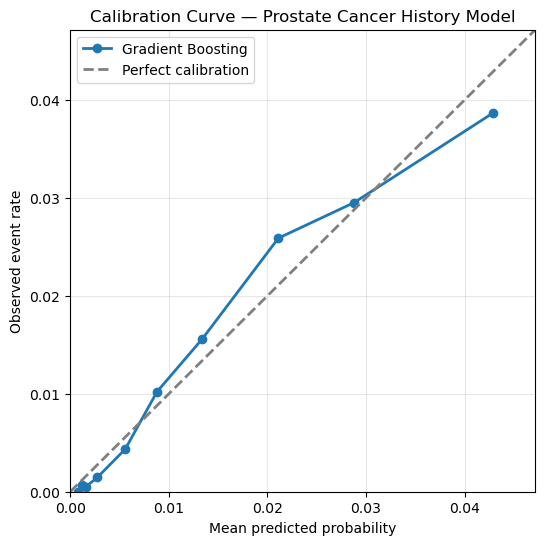


Cancer-history calibration points
---------------------------------


,Mean predicted probability,Observed rate
0,0.0008,0.0000
1,0.0012,0.0007
2,0.0016,0.0005
3,0.0027,0.0015
4,0.0056,0.0043
5,0.0088,0.0102
6,0.0134,0.0156
7,0.0211,0.0259
8,0.0288,0.0295
9,0.0429,0.0387



Cancer-history probability deciles
----------------------------------


,cancer_history_decile,n,observed_events,observed_rate,mean_predicted_probability,min_predicted_probability,max_predicted_probability
0,1,4156,0,0.0000,0.0008,0.0003,0.0011
1,2,4076,3,0.0007,0.0012,0.0011,0.0013
2,3,4115,2,0.0005,0.0016,0.0013,0.0020
3,4,4114,6,0.0015,0.0027,0.0020,0.0042
4,5,4140,18,0.0043,0.0056,0.0042,0.0068
5,6,4114,42,0.0102,0.0088,0.0068,0.0109
6,7,4104,64,0.0156,0.0134,0.0109,0.0169
7,8,4095,106,0.0259,0.0211,0.0169,0.0246
8,9,4168,123,0.0295,0.0288,0.0246,0.0338
9,10,4061,157,0.0387,0.0429,0.0338,0.3159



Cancer-history top-risk capture
-------------------------------


,Metric,Value
0,Observed cases in test set,521.0000
1,Cases captured in top decile,157.0000
2,Share captured in top decile,0.3013
3,Cases captured in top two deciles,280.0000
4,Share captured in top two deciles,0.5374


In [10]:
# ============================================================
# 9. CANCER-HISTORY MODEL CALIBRATION AND DECILES
# ============================================================

final_cancer_model_name = "Gradient Boosting"
final_cancer_model = fitted_cancer_models[final_cancer_model_name]
final_cancer_probs_test = cancer_probs[final_cancer_model_name]

cancer_test_results = X_cancer_test.copy()
cancer_test_results["y_true"] = y_cancer_test.values
cancer_test_results["pred_cancer_history_prob"] = final_cancer_probs_test

cancer_calibration_df = plot_calibration_curve(
    y_true=cancer_test_results["y_true"],
    y_prob=cancer_test_results["pred_cancer_history_prob"],
    title="Calibration Curve — Prostate Cancer History Model",
    label=final_cancer_model_name,
    filename="figure_cancer_history_calibration.png",
    n_bins=10
)

display_table(cancer_calibration_df, "Cancer-history calibration points")

save_table(cancer_calibration_df, "table_cancer_calibration_points.csv")


cancer_test_results, cancer_decile_table = create_decile_summary(
    df=cancer_test_results,
    y_col="y_true",
    prob_col="pred_cancer_history_prob",
    decile_col="cancer_history_decile"
)

display_table(cancer_decile_table, "Cancer-history probability deciles")

save_table(cancer_decile_table, "table_cancer_history_deciles.csv")


top_decile = cancer_decile_table["cancer_history_decile"].max()

total_cases_test = cancer_test_results["y_true"].sum()

top_decile_cases = cancer_decile_table.loc[
    cancer_decile_table["cancer_history_decile"] == top_decile,
    "observed_events"
].iloc[0]

top_two_decile_cases = cancer_decile_table.loc[
    cancer_decile_table["cancer_history_decile"].isin([top_decile, top_decile - 1]),
    "observed_events"
].sum()

cancer_capture_summary = pd.DataFrame({
    "Metric": [
        "Observed cases in test set",
        "Cases captured in top decile",
        "Share captured in top decile",
        "Cases captured in top two deciles",
        "Share captured in top two deciles"
    ],
    "Value": [
        total_cases_test,
        top_decile_cases,
        top_decile_cases / total_cases_test,
        top_two_decile_cases,
        top_two_decile_cases / total_cases_test
    ]
})

display_table(cancer_capture_summary, "Cancer-history top-risk capture")

save_table(cancer_capture_summary, "table_cancer_top_risk_capture.csv")


## 10. GENERATE FULL-SAMPLE CANCER-HISTORY PROBABILITY SCORES

In [11]:
# ============================================================
# 10. GENERATE FULL-SAMPLE CANCER-HISTORY PROBABILITY SCORES
# ============================================================

cancer_valid_df = df_model[
    df_model[TARGET_CANCER].notna()
].copy()

X_cancer_valid = cancer_valid_df[features_cancer].copy()

cancer_valid_df["pred_cancer_history_prob"] = final_cancer_model.predict_proba(
    X_cancer_valid
)[:, 1]

cancer_valid_df["pred_cancer_history_prob_pct"] = (
    cancer_valid_df["pred_cancer_history_prob"] * 100
)

df_model["pred_cancer_history_prob"] = np.nan
df_model["pred_cancer_history_prob_pct"] = np.nan

df_model.loc[
    cancer_valid_df.index,
    "pred_cancer_history_prob"
] = cancer_valid_df["pred_cancer_history_prob"]

df_model.loc[
    cancer_valid_df.index,
    "pred_cancer_history_prob_pct"
] = cancer_valid_df["pred_cancer_history_prob_pct"]


df_model["cancer_history_decile_full"] = np.nan

df_model.loc[
    cancer_valid_df.index,
    "cancer_history_decile_full"
] = pd.qcut(
    cancer_valid_df["pred_cancer_history_prob"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1


full_cancer_score_summary = pd.DataFrame({
    "Metric": [
        "Scored observations",
        "Observed prevalence among scored",
        "Mean predicted probability",
        "Minimum predicted probability",
        "Median predicted probability",
        "Maximum predicted probability"
    ],
    "Value": [
        df_model["pred_cancer_history_prob"].notna().sum(),
        df_model.loc[df_model["pred_cancer_history_prob"].notna(), TARGET_CANCER].mean(),
        df_model["pred_cancer_history_prob"].mean(),
        df_model["pred_cancer_history_prob"].min(),
        df_model["pred_cancer_history_prob"].median(),
        df_model["pred_cancer_history_prob"].max()
    ]
})

display_table(full_cancer_score_summary, "Full-sample cancer-history score summary")

save_table(full_cancer_score_summary, "table_full_cancer_score_summary.csv")



Full-sample cancer-history score summary
----------------------------------------


,Metric,Value
0,Scored observations,137141.0000
1,Observed prevalence among scored,0.0127
2,Mean predicted probability,0.0127
3,Minimum predicted probability,0.0003
4,Median predicted probability,0.0068
5,Maximum predicted probability,0.5714


## 11. PREPARE PSA UTILIZATION MODEL DATASET


In [12]:
# ============================================================
# 11. PREPARE PSA UTILIZATION MODEL DATASET
# ============================================================

TARGET_PSA = "had_psa"

numeric_features_psa = [
    "age",
    "black",
    "has_insurance",
    "has_personal_doctor",
    "bmi",
    "pred_cancer_history_prob"
]

categorical_features_psa = [
    "age_group",
    "race_cat",
    "education_cat",
    "income_cat",
    "general_health_cat"
]

features_psa = numeric_features_psa + categorical_features_psa

psa_ml_df = df_model[
    df_model[TARGET_PSA].notna() &
    df_model["pred_cancer_history_prob"].notna()
].copy()

X_psa = psa_ml_df[features_psa].copy()
y_psa = psa_ml_df[TARGET_PSA].astype(int).copy()

X_psa_train, X_psa_test, y_psa_train, y_psa_test = train_test_split(
    X_psa,
    y_psa,
    test_size=0.30,
    random_state=42,
    stratify=y_psa
)

psa_dataset_summary = pd.DataFrame({
    "Quantity": [
        "PSA modeling sample N",
        "PSA positives",
        "PSA negatives",
        "Observed PSA utilization prevalence",
        "Training N",
        "Test N"
    ],
    "Value": [
        len(psa_ml_df),
        int(y_psa.sum()),
        int((y_psa == 0).sum()),
        y_psa.mean(),
        len(X_psa_train),
        len(X_psa_test)
    ]
})

display_table(psa_dataset_summary, "PSA utilization modeling dataset summary")

save_table(psa_dataset_summary, "table_psa_dataset_summary.csv")



PSA utilization modeling dataset summary
----------------------------------------


,Quantity,Value
0,PSA modeling sample N,5809.0000
1,PSA positives,3277.0000
2,PSA negatives,2532.0000
3,Observed PSA utilization prevalence,0.5641
4,Training N,4066.0000
5,Test N,1743.0000


## 12. TRAIN PSA UTILIZATION MODELS

In [13]:
# ============================================================
# 12. TRAIN PSA UTILIZATION MODELS
# ============================================================

preprocess_psa = build_preprocessor(
    numeric_features=numeric_features_psa,
    categorical_features=categorical_features_psa
)

psa_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver="lbfgs"
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=2,
        min_samples_leaf=20,
        random_state=42
    )
}

fitted_psa_models, psa_probs, psa_results = train_and_compare_models(
    models=psa_models,
    preprocessor=preprocess_psa,
    X_train=X_psa_train,
    X_test=X_psa_test,
    y_train=y_psa_train,
    y_test=y_psa_test
)

psa_results_sorted = psa_results.sort_values(
    by=["Brier score", "AUC"],
    ascending=[True, False]
)

display_table(psa_results_sorted, "PSA utilization model performance")

save_table(psa_results_sorted, "table_psa_model_performance.csv")



PSA utilization model performance
---------------------------------


,Model,AUC,Average precision,Brier score,Mean predicted probability,Observed prevalence,Accuracy,Sensitivity,Specificity,Precision,F1,TP,FP,TN,FN
0,Logistic Regression,0.8003,0.8162,0.1782,0.5582,0.564,0.7430,0.8403,0.6171,0.7395,0.7867,826,291,469,157
2,Gradient Boosting,0.7917,0.8108,0.1824,0.5578,0.564,0.7315,0.8189,0.6184,0.7352,0.7748,805,290,470,178
1,Random Forest,0.7886,0.8081,0.1843,0.5583,0.564,0.7303,0.8342,0.5961,0.7276,0.7773,820,307,453,163


## 13. PSA UTILIZATION MODEL CALIBRATION AND DECILES

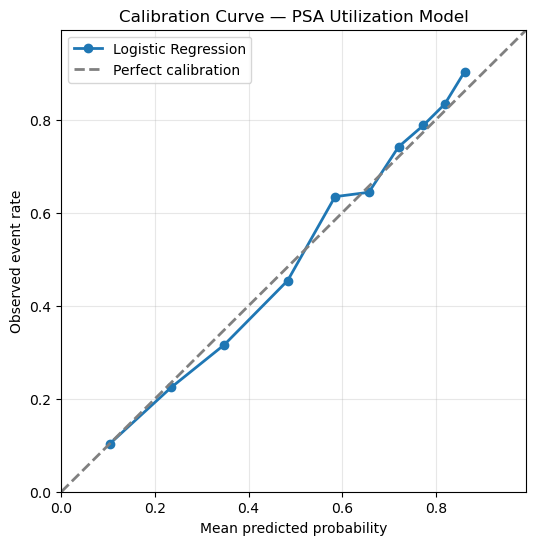


PSA calibration points
----------------------


,Mean predicted probability,Observed rate
0,0.1031,0.1029
1,0.2344,0.2241
2,0.3481,0.3161
3,0.4833,0.4540
4,0.5845,0.6343
5,0.6567,0.6437
6,0.7201,0.7414
7,0.7728,0.7874
8,0.8188,0.8333
9,0.8612,0.9029



PSA propensity deciles
----------------------


,psa_propensity_decile,n,observed_events,observed_rate,mean_predicted_probability,min_predicted_probability,max_predicted_probability
0,1,175,18,0.1029,0.1031,0.0110,0.1756
1,2,174,39,0.2241,0.2344,0.1758,0.2890
2,3,174,55,0.3161,0.3481,0.2895,0.4148
3,4,174,79,0.4540,0.4833,0.4152,0.5414
4,5,175,111,0.6343,0.5845,0.5419,0.6204
5,6,174,112,0.6437,0.6567,0.6219,0.6913
6,7,174,129,0.7414,0.7201,0.6915,0.7484
7,8,174,137,0.7874,0.7728,0.7489,0.7961
8,9,174,145,0.8333,0.8188,0.7962,0.8410
9,10,175,158,0.9029,0.8612,0.8416,0.9131


In [14]:
# ============================================================
# 13. PSA UTILIZATION MODEL CALIBRATION AND DECILES
# ============================================================

final_psa_model_name = "Logistic Regression"
final_psa_model = fitted_psa_models[final_psa_model_name]
final_psa_probs_test = psa_probs[final_psa_model_name]

psa_test_results = X_psa_test.copy()
psa_test_results["y_true"] = y_psa_test.values
psa_test_results["pred_psa_propensity"] = final_psa_probs_test

psa_calibration_df = plot_calibration_curve(
    y_true=psa_test_results["y_true"],
    y_prob=psa_test_results["pred_psa_propensity"],
    title="Calibration Curve — PSA Utilization Model",
    label=final_psa_model_name,
    filename="figure_psa_utilization_calibration.png",
    n_bins=10
)

display_table(psa_calibration_df, "PSA calibration points")

save_table(psa_calibration_df, "table_psa_calibration_points.csv")


psa_test_results, psa_decile_table = create_decile_summary(
    df=psa_test_results,
    y_col="y_true",
    prob_col="pred_psa_propensity",
    decile_col="psa_propensity_decile"
)

display_table(psa_decile_table, "PSA propensity deciles")

save_table(psa_decile_table, "table_psa_propensity_deciles.csv")


## 14. GENERATE FULL-SAMPLE PSA PROPENSITY SCORES

In [15]:
# ============================================================
# 14. GENERATE FULL-SAMPLE PSA PROPENSITY SCORES
# ============================================================

psa_valid_df = df_model[
    df_model[TARGET_PSA].notna() &
    df_model["pred_cancer_history_prob"].notna()
].copy()

X_psa_valid = psa_valid_df[features_psa].copy()

psa_valid_df["pred_psa_propensity"] = final_psa_model.predict_proba(
    X_psa_valid
)[:, 1]

psa_valid_df["pred_psa_propensity_pct"] = (
    psa_valid_df["pred_psa_propensity"] * 100
)

df_model["pred_psa_propensity"] = np.nan
df_model["pred_psa_propensity_pct"] = np.nan

df_model.loc[
    psa_valid_df.index,
    "pred_psa_propensity"
] = psa_valid_df["pred_psa_propensity"]

df_model.loc[
    psa_valid_df.index,
    "pred_psa_propensity_pct"
] = psa_valid_df["pred_psa_propensity_pct"]


df_model["psa_propensity_decile_full"] = np.nan

df_model.loc[
    psa_valid_df.index,
    "psa_propensity_decile_full"
] = pd.qcut(
    psa_valid_df["pred_psa_propensity"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1


full_psa_score_summary = pd.DataFrame({
    "Metric": [
        "Scored observations",
        "Observed PSA utilization rate among scored",
        "Mean predicted PSA propensity",
        "Minimum predicted PSA propensity",
        "Median predicted PSA propensity",
        "Maximum predicted PSA propensity"
    ],
    "Value": [
        df_model["pred_psa_propensity"].notna().sum(),
        df_model.loc[df_model["pred_psa_propensity"].notna(), TARGET_PSA].mean(),
        df_model["pred_psa_propensity"].mean(),
        df_model["pred_psa_propensity"].min(),
        df_model["pred_psa_propensity"].median(),
        df_model["pred_psa_propensity"].max()
    ]
})

display_table(full_psa_score_summary, "Full-sample PSA propensity score summary")

save_table(full_psa_score_summary, "table_full_psa_score_summary.csv")



Full-sample PSA propensity score summary
----------------------------------------


,Metric,Value
0,Scored observations,5809.0000
1,Observed PSA utilization rate among scored,0.5641
2,Mean predicted PSA propensity,0.5625
3,Minimum predicted PSA propensity,0.0110
4,Median predicted PSA propensity,0.6279
5,Maximum predicted PSA propensity,0.9131


## 15. CREATE NASH-READY DATASET

In [16]:
# ============================================================
# 15. CREATE NASH-READY DATASET
# ============================================================

nash_df = df_model[
    df_model["pred_cancer_history_prob"].notna() &
    df_model["pred_psa_propensity"].notna() &
    df_model["cancer_history_decile_full"].notna() &
    df_model["psa_propensity_decile_full"].notna()
].copy()

nash_ready_summary = pd.DataFrame({
    "Metric": [
        "Nash-ready sample N",
        "Observed PSA utilization rate",
        "Observed self-reported prostate cancer history prevalence",
        "Mean predicted cancer-history probability",
        "Mean predicted PSA propensity"
    ],
    "Value": [
        len(nash_df),
        nash_df["had_psa"].mean(),
        nash_df["had_prostate_cancer"].mean(),
        nash_df["pred_cancer_history_prob"].mean(),
        nash_df["pred_psa_propensity"].mean()
    ]
})

display_table(nash_ready_summary, "Nash-ready sample summary")

save_table(nash_ready_summary, "table_nash_ready_summary.csv")



Nash-ready sample summary
-------------------------


,Metric,Value
0,Nash-ready sample N,5809.0000
1,Observed PSA utilization rate,0.5641
2,Observed self-reported prostate cancer history...,0.0153
3,Mean predicted cancer-history probability,0.0139
4,Mean predicted PSA propensity,0.5625


## 16. STRATEGIC RISK-PROPENSITY ZONES

In [17]:
# ============================================================
# 16. STRATEGIC RISK-PROPENSITY ZONES
# ============================================================

def assign_broad_zone(row):
    cancer_decile = row["cancer_history_decile_full"]
    psa_decile = row["psa_propensity_decile_full"]

    if cancer_decile >= 7 and psa_decile <= 5:
        return "Elevated cancer-history signal / Low-to-moderate PSA propensity"
    
    elif cancer_decile >= 7 and psa_decile >= 7:
        return "Elevated cancer-history signal / High PSA propensity"
    
    elif cancer_decile <= 4 and psa_decile >= 6:
        return "Low cancer-history signal / Moderate-to-high PSA propensity"
    
    elif cancer_decile <= 4 and psa_decile <= 5:
        return "Low cancer-history signal / Low-to-moderate PSA propensity"
    
    else:
        return "Intermediate"


nash_df["strategic_zone"] = nash_df.apply(assign_broad_zone, axis=1)


strategic_zone_summary = (
    nash_df
    .groupby("strategic_zone")
    .agg(
        n=("had_psa", "size"),
        observed_psa_rate=("had_psa", "mean"),
        mean_predicted_psa_propensity=("pred_psa_propensity", "mean"),
        observed_cancer_history_rate=("had_prostate_cancer", "mean"),
        mean_predicted_cancer_history_prob=("pred_cancer_history_prob", "mean")
    )
    .reset_index()
    .sort_values("mean_predicted_cancer_history_prob", ascending=False)
)

display_table(strategic_zone_summary, "Strategic risk--propensity zone summary")

save_table(strategic_zone_summary, "table_strategic_zone_summary.csv")



Strategic risk--propensity zone summary
---------------------------------------


,strategic_zone,n,observed_psa_rate,mean_predicted_psa_propensity,observed_cancer_history_rate,mean_predicted_cancer_history_prob
0,Elevated cancer-history signal / High PSA prop...,1898,0.8193,0.8049,0.0306,0.0289
1,Elevated cancer-history signal / Low-to-modera...,362,0.5249,0.5297,0.0331,0.0204
2,Intermediate,1446,0.6058,0.6153,0.0104,0.0105
4,Low cancer-history signal / Moderate-to-high P...,98,0.6633,0.6618,0.0000,0.0028
3,Low cancer-history signal / Low-to-moderate PS...,2005,0.2948,0.2959,0.0020,0.0016


## 17. HEATMAP: OBSERVED PSA RATE BY RISK AND PROPENSITY DECILES

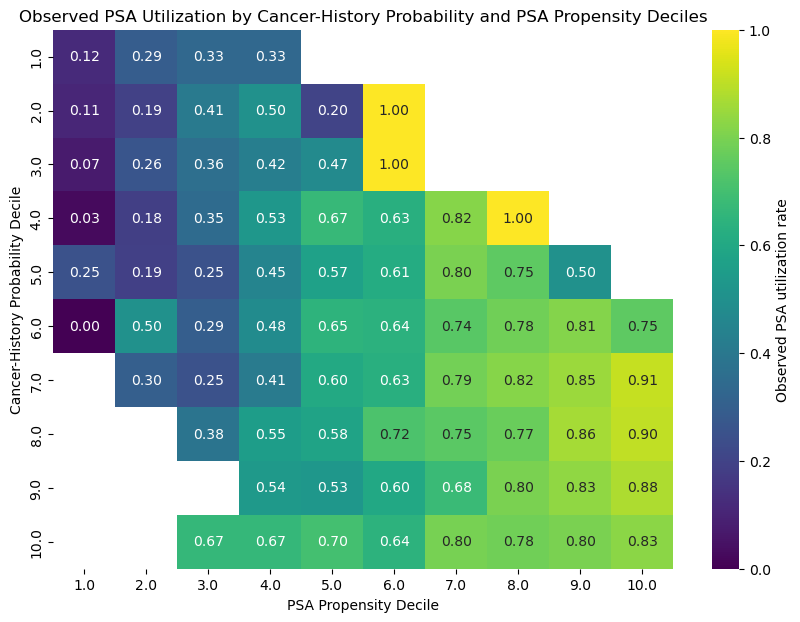

In [18]:
# ============================================================
# 17. HEATMAP: OBSERVED PSA RATE BY RISK AND PROPENSITY DECILES
# ============================================================

heatmap_psa_rate = (
    nash_df
    .groupby(["cancer_history_decile_full", "psa_propensity_decile_full"])
    ["had_psa"]
    .mean()
    .unstack()
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    heatmap_psa_rate,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "Observed PSA utilization rate"}
)

plt.title("Observed PSA Utilization by Cancer-History Probability and PSA Propensity Deciles")
plt.xlabel("PSA Propensity Decile")
plt.ylabel("Cancer-History Probability Decile")

save_figure("figure_heatmap_psa_by_risk_propensity.png")

if SHOW_PLOTS:
    plt.show()
else:
    plt.close()


## 18. INTERVENTION PRIORITY SCORE

In [19]:
# ============================================================
# 18. INTERVENTION PRIORITY SCORE
# ============================================================

priority_df = nash_df.copy()

priority_df["risk_rank"] = (
    priority_df["pred_cancer_history_prob"]
    .rank(pct=True)
)

priority_df["screening_barrier"] = (
    1 - priority_df["pred_psa_propensity"]
)

priority_df["screening_barrier_rank"] = (
    priority_df["screening_barrier"]
    .rank(pct=True)
)

priority_df["priority_score"] = (
    priority_df["risk_rank"] *
    priority_df["screening_barrier_rank"]
)

priority_df["priority_decile"] = pd.qcut(
    priority_df["priority_score"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1


priority_zone_summary = (
    priority_df
    .groupby("strategic_zone")
    .agg(
        n=("had_psa", "size"),
        observed_psa_rate=("had_psa", "mean"),
        mean_predicted_cancer_history_prob=("pred_cancer_history_prob", "mean"),
        mean_predicted_psa_propensity=("pred_psa_propensity", "mean"),
        mean_screening_barrier=("screening_barrier", "mean"),
        mean_priority_score=("priority_score", "mean")
    )
    .reset_index()
    .sort_values("mean_priority_score", ascending=False)
)

display_table(priority_zone_summary, "Priority score by strategic zone")

save_table(priority_zone_summary, "table_priority_by_zone.csv")



Priority score by strategic zone
--------------------------------


,strategic_zone,n,observed_psa_rate,mean_predicted_cancer_history_prob,mean_predicted_psa_propensity,mean_screening_barrier,mean_priority_score
1,Elevated cancer-history signal / Low-to-modera...,362,0.5249,0.0204,0.5297,0.4703,0.4221
2,Intermediate,1446,0.6058,0.0105,0.6153,0.3847,0.2439
4,Low cancer-history signal / Moderate-to-high P...,98,0.6633,0.0028,0.6618,0.3382,0.1400
0,Elevated cancer-history signal / High PSA prop...,1898,0.8193,0.0289,0.8049,0.1951,0.1398
3,Low cancer-history signal / Low-to-moderate PS...,2005,0.2948,0.0016,0.2959,0.7041,0.1310


## 19. ORDINAL NASH GAME: PAYOFF PARAMETERS AND PAYOFFS

In [20]:
# ============================================================
# 19. ORDINAL NASH GAME: PAYOFF PARAMETERS AND PAYOFFS
# ============================================================

nash_game_df = priority_df.copy()

# Ordinal inputs
nash_game_df["R"] = nash_game_df["risk_rank"]
nash_game_df["F"] = nash_game_df["screening_barrier_rank"]
nash_game_df["L"] = 1 - nash_game_df["R"]


# -----------------------------
# Payoff parameters
# -----------------------------

patient_friction_weight = 0.60
recommendation_friction_reduction = 0.50

system_screening_cost = 0.20
system_outreach_cost = 0.10
missed_high_risk_penalty = 0.70
overuse_penalty_weight = 0.30


def compute_payoffs(row):
    R = row["R"]
    F = row["F"]
    L = row["L"]

    # Patient strategies:
    # P0 = no PSA
    # P1 = PSA

    # System strategies:
    # S0 = no recommendation
    # S1 = recommend/facilitate

    patient_P1_S1 = R - patient_friction_weight * F * (1 - recommendation_friction_reduction)
    patient_P1_S0 = R - patient_friction_weight * F
    patient_P0_S1 = -R
    patient_P0_S0 = L - R

    system_P1_S1 = R - system_screening_cost - system_outreach_cost
    system_P1_S0 = 0.50 * R - system_screening_cost
    system_P0_S1 = -system_outreach_cost - missed_high_risk_penalty * R
    system_P0_S0 = -missed_high_risk_penalty * R

    # Overuse penalty when screening occurs at low predicted risk signal
    system_P1_S1 = system_P1_S1 - overuse_penalty_weight * L
    system_P1_S0 = system_P1_S0 - overuse_penalty_weight * L

    return pd.Series({
        "patient_payoff_P0_S0": patient_P0_S0,
        "patient_payoff_P0_S1": patient_P0_S1,
        "patient_payoff_P1_S0": patient_P1_S0,
        "patient_payoff_P1_S1": patient_P1_S1,
        "system_payoff_P0_S0": system_P0_S0,
        "system_payoff_P0_S1": system_P0_S1,
        "system_payoff_P1_S0": system_P1_S0,
        "system_payoff_P1_S1": system_P1_S1
    })


payoff_cols = nash_game_df.apply(compute_payoffs, axis=1)

nash_game_df = pd.concat([nash_game_df, payoff_cols], axis=1)


## 20. DETERMINE ORDINAL NASH EQUILIBRIA

In [21]:
# ============================================================
# 20. DETERMINE ORDINAL NASH EQUILIBRIA
# ============================================================

def determine_nash(row):
    # Patient best responses conditional on system strategy
    patient_best_if_S0 = (
        "P1" if row["patient_payoff_P1_S0"] > row["patient_payoff_P0_S0"] else "P0"
    )
    
    patient_best_if_S1 = (
        "P1" if row["patient_payoff_P1_S1"] > row["patient_payoff_P0_S1"] else "P0"
    )

    # System best responses conditional on patient strategy
    system_best_if_P0 = (
        "S1" if row["system_payoff_P0_S1"] > row["system_payoff_P0_S0"] else "S0"
    )
    
    system_best_if_P1 = (
        "S1" if row["system_payoff_P1_S1"] > row["system_payoff_P1_S0"] else "S0"
    )

    equilibria = []

    if patient_best_if_S0 == "P0" and system_best_if_P0 == "S0":
        equilibria.append("P0_S0")

    if patient_best_if_S1 == "P0" and system_best_if_P0 == "S1":
        equilibria.append("P0_S1")

    if patient_best_if_S0 == "P1" and system_best_if_P1 == "S0":
        equilibria.append("P1_S0")

    if patient_best_if_S1 == "P1" and system_best_if_P1 == "S1":
        equilibria.append("P1_S1")

    if len(equilibria) == 0:
        nash_type = "No pure equilibrium"
    elif len(equilibria) == 1:
        nash_type = equilibria[0]
    else:
        nash_type = "Multiple: " + ",".join(equilibria)

    return pd.Series({
        "patient_best_if_S0": patient_best_if_S0,
        "patient_best_if_S1": patient_best_if_S1,
        "system_best_if_P0": system_best_if_P0,
        "system_best_if_P1": system_best_if_P1,
        "nash_equilibrium": nash_type
    })


nash_results = nash_game_df.apply(determine_nash, axis=1)

nash_game_df = pd.concat([nash_game_df, nash_results], axis=1)


nash_equilibrium_summary = (
    nash_game_df
    .groupby("nash_equilibrium")
    .agg(
        n=("had_psa", "size"),
        observed_psa_rate=("had_psa", "mean"),
        mean_predicted_cancer_history_prob=("pred_cancer_history_prob", "mean"),
        mean_predicted_psa_propensity=("pred_psa_propensity", "mean"),
        observed_cancer_history_rate=("had_prostate_cancer", "mean"),
        mean_priority_score=("priority_score", "mean")
    )
    .reset_index()
    .sort_values("mean_predicted_cancer_history_prob", ascending=False)
)

display_table(nash_equilibrium_summary, "Nash equilibrium summary")

save_table(nash_equilibrium_summary, "table_nash_equilibrium_summary.csv")



Nash equilibrium summary
------------------------


,nash_equilibrium,n,observed_psa_rate,mean_predicted_cancer_history_prob,mean_predicted_psa_propensity,observed_cancer_history_rate,mean_priority_score
2,P1_S1,3273,0.7409,0.0230,0.7330,0.0260,0.2018
0,"Multiple: P0_S0,P1_S1",1372,0.4380,0.0033,0.4531,0.0022,0.2103
1,P0_S0,1164,0.2156,0.0011,0.2118,0.0009,0.0844


In [38]:
# ============================================================
# 20B. SENSITIVITY ANALYSIS OF NASH PAYOFF ASSUMPTIONS
# Conservative base-case specification
# ============================================================

from sklearn.metrics import cohen_kappa_score, confusion_matrix

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_cols_sensitivity = [
    "had_psa",
    "patient_payoff_P1_S0",
    "patient_payoff_P0_S0",
    "patient_payoff_P1_S1",
    "patient_payoff_P0_S1",
    "system_payoff_P0_S1",
    "system_payoff_P0_S0",
    "system_payoff_P1_S1",
    "system_payoff_P1_S0"
]

missing_cols_sensitivity = [
    col for col in required_cols_sensitivity
    if col not in nash_game_df.columns
]

if len(missing_cols_sensitivity) > 0:
    raise ValueError(
        f"Missing columns needed for Nash payoff sensitivity analysis: {missing_cols_sensitivity}"
    )


# ------------------------------------------------------------
# Helper function: screening-favorable coding
# ------------------------------------------------------------

def code_screening_favorable_from_equilibrium(eq):
    """
    Screening-favorable Nash coding.

    A respondent is classified as screening-favorable if the Nash equilibrium
    includes patient screening action P1.

    The conservative nature of the base-case specification is implemented
    through the payoff perturbation, specifically by applying a system
    screening-support penalty of -1 in the base-case scenario.
    """
    if pd.isna(eq):
        return np.nan
    
    eq_str = str(eq)
    
    if "P1" in eq_str:
        return 1
    else:
        return 0


# ------------------------------------------------------------
# Helper function: run Nash after payoff perturbation
# ------------------------------------------------------------

def run_nash_sensitivity_scenario(
    df,
    scenario_name,
    patient_screen_delta=0,
    patient_no_screen_delta=0,
    system_recommend_delta=0,
    system_no_recommend_delta=0
):
    """
    Applies additive perturbations to existing ordinal payoff columns and
    recalculates Nash equilibria using the same determine_nash function.

    patient_screen_delta:
        Additive change applied to patient payoff when choosing P1.

    patient_no_screen_delta:
        Additive change applied to patient payoff when choosing P0.

    system_recommend_delta:
        Additive change applied to system payoff when choosing S1.

    system_no_recommend_delta:
        Additive change applied to system payoff when choosing S0.
    """
    
    temp = df.copy()
    
    # Patient screening action P1
    temp["patient_payoff_P1_S0"] = (
        temp["patient_payoff_P1_S0"] + patient_screen_delta
    )
    temp["patient_payoff_P1_S1"] = (
        temp["patient_payoff_P1_S1"] + patient_screen_delta
    )
    
    # Patient no-screening action P0
    temp["patient_payoff_P0_S0"] = (
        temp["patient_payoff_P0_S0"] + patient_no_screen_delta
    )
    temp["patient_payoff_P0_S1"] = (
        temp["patient_payoff_P0_S1"] + patient_no_screen_delta
    )
    
    # System recommendation / screening-support action S1
    temp["system_payoff_P0_S1"] = (
        temp["system_payoff_P0_S1"] + system_recommend_delta
    )
    temp["system_payoff_P1_S1"] = (
        temp["system_payoff_P1_S1"] + system_recommend_delta
    )
    
    # System no-recommendation / no-support action S0
    temp["system_payoff_P0_S0"] = (
        temp["system_payoff_P0_S0"] + system_no_recommend_delta
    )
    temp["system_payoff_P1_S0"] = (
        temp["system_payoff_P1_S0"] + system_no_recommend_delta
    )
    
    # Recalculate Nash equilibria
    sensitivity_nash_results = temp.apply(determine_nash, axis=1)
    
    temp = pd.concat(
        [
            temp.drop(
                columns=[
                    "patient_best_if_S0",
                    "patient_best_if_S1",
                    "system_best_if_P0",
                    "system_best_if_P1",
                    "nash_equilibrium"
                ],
                errors="ignore"
            ),
            sensitivity_nash_results
        ],
        axis=1
    )
    
    temp["eq_screen_sensitivity"] = (
        temp["nash_equilibrium"]
        .apply(code_screening_favorable_from_equilibrium)
    )
    
    temp["scenario"] = scenario_name
    
    return temp


# ------------------------------------------------------------
# Define sensitivity scenarios around the conservative base case
# ------------------------------------------------------------

# IMPORTANT:
# The validated conservative base-case Nash specification corresponds to
# a system screening-support penalty of -1.
# This reproduces:
# Nash screening-favorable rate ≈ 0.5634
# Overall agreement ≈ 0.7074
# Cohen kappa ≈ 0.4050
# Target A N ≈ 848

nash_sensitivity_scenarios = [
    {
        "scenario_name": "Base case conservative specification",
        "patient_screen_delta": 0,
        "patient_no_screen_delta": 0,
        "system_recommend_delta": -1,
        "system_no_recommend_delta": 0
    },
    {
        "scenario_name": "Higher patient screening burden",
        "patient_screen_delta": -1,
        "patient_no_screen_delta": 0,
        "system_recommend_delta": -1,
        "system_no_recommend_delta": 0
    },
    {
        "scenario_name": "Lower patient screening burden",
        "patient_screen_delta": 1,
        "patient_no_screen_delta": 0,
        "system_recommend_delta": -1,
        "system_no_recommend_delta": 0
    },
    {
        "scenario_name": "Higher system friction",
        "patient_screen_delta": 0,
        "patient_no_screen_delta": 0,
        "system_recommend_delta": -2,
        "system_no_recommend_delta": 0
    },
    {
        "scenario_name": "Lower system friction",
        "patient_screen_delta": 0,
        "patient_no_screen_delta": 0,
        "system_recommend_delta": 0,
        "system_no_recommend_delta": 0
    },
    {
        "scenario_name": "More screening-favorable payoffs",
        "patient_screen_delta": 1,
        "patient_no_screen_delta": 0,
        "system_recommend_delta": 0,
        "system_no_recommend_delta": 0
    },
    {
        "scenario_name": "Less screening-favorable payoffs",
        "patient_screen_delta": -1,
        "patient_no_screen_delta": 0,
        "system_recommend_delta": -2,
        "system_no_recommend_delta": 0
    }
]


# ------------------------------------------------------------
# Create Target C indicator if not already present
# ------------------------------------------------------------

if "target_C" not in nash_game_df.columns:
    
    possible_zone_cols = [
        "strategic_zone",
        "risk_propensity_zone",
        "risk_psa_zone",
        "zone"
    ]
    
    zone_col = None
    
    for col in possible_zone_cols:
        if col in nash_game_df.columns:
            zone_col = col
            break
    
    if zone_col is None:
        print(
            "No strategic-zone column found. "
            "Target C Nash-favorable rate will be set to missing."
        )
        nash_game_df["target_C"] = np.nan
    
    else:
        nash_game_df["target_C"] = (
            (nash_game_df["had_psa"] == 0) &
            (
                nash_game_df[zone_col]
                .astype(str)
                .str.contains("Elevated", case=False, na=False)
            ) &
            (
                nash_game_df[zone_col]
                .astype(str)
                .str.contains("Low", case=False, na=False)
            )
        ).astype(int)


# ------------------------------------------------------------
# Run base-case conservative scenario first
# ------------------------------------------------------------

base_case_df = run_nash_sensitivity_scenario(
    nash_game_df,
    scenario_name="Base case conservative specification",
    patient_screen_delta=0,
    patient_no_screen_delta=0,
    system_recommend_delta=-1,
    system_no_recommend_delta=0
)

base_case_classification = (
    base_case_df["eq_screen_sensitivity"]
    .astype(int)
)


# ------------------------------------------------------------
# Quick diagnostic for base-case conservative specification
# ------------------------------------------------------------

base_case_check = base_case_df[
    base_case_df["had_psa"].notna() &
    base_case_df["eq_screen_sensitivity"].notna()
].copy()

base_y_obs = base_case_check["had_psa"].astype(int)
base_y_nash = base_case_check["eq_screen_sensitivity"].astype(int)

base_tn, base_fp, base_fn, base_tp = confusion_matrix(
    base_y_obs,
    base_y_nash
).ravel()

base_nash_rate = base_y_nash.mean()
base_agreement = (base_tp + base_tn) / len(base_case_check)
base_kappa = cohen_kappa_score(base_y_obs, base_y_nash)
base_target_a_n = ((base_y_obs == 0) & (base_y_nash == 1)).sum()

print("Base-case conservative Nash check")
print("---------------------------------")
print(f"N = {len(base_case_check)}")
print(f"Nash screening-favorable rate = {base_nash_rate:.4f}")
print(f"Overall agreement with observed PSA = {base_agreement:.4f}")
print(f"Cohen kappa = {base_kappa:.4f}")
print(f"Target A N = {base_target_a_n}")


# ------------------------------------------------------------
# Run all sensitivity scenarios
# ------------------------------------------------------------

sensitivity_results = []

for scenario in nash_sensitivity_scenarios:
    
    scenario_df = run_nash_sensitivity_scenario(
        nash_game_df,
        **scenario
    )
    
    valid_df = scenario_df[
        scenario_df["had_psa"].notna() &
        scenario_df["eq_screen_sensitivity"].notna()
    ].copy()
    
    y_obs = valid_df["had_psa"].astype(int)
    y_nash = valid_df["eq_screen_sensitivity"].astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_obs, y_nash).ravel()
    
    n = len(valid_df)
    observed_psa_rate = y_obs.mean()
    nash_screening_rate = y_nash.mean()
    overall_agreement = (tp + tn) / n
    kappa = cohen_kappa_score(y_obs, y_nash)
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    balanced_accuracy = np.nanmean([sensitivity, specificity])
    
    # Target A = no observed PSA utilization despite screening-favorable Nash classification
    target_a_n = ((y_obs == 0) & (y_nash == 1)).sum()
    
    # Target C Nash-favorable rate
    if "target_C" in valid_df.columns and valid_df["target_C"].notna().any():
        target_c_df = valid_df[valid_df["target_C"] == 1]
        target_c_n = len(target_c_df)
        target_c_nash_favorable_rate = (
            target_c_df["eq_screen_sensitivity"].mean()
            if target_c_n > 0 else np.nan
        )
    else:
        target_c_n = np.nan
        target_c_nash_favorable_rate = np.nan
    
    # Agreement with base-case conservative Nash classification
    base_case_agreement = (
        y_nash.values == base_case_classification.loc[valid_df.index].values
    ).mean()
    
    sensitivity_results.append({
        "Scenario": scenario["scenario_name"],
        "N": n,
        "Observed PSA utilization rate": observed_psa_rate,
        "Nash screening-favorable rate": nash_screening_rate,
        "Overall agreement with observed PSA": overall_agreement,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Balanced accuracy": balanced_accuracy,
        "Cohen kappa": kappa,
        "Target A N": target_a_n,
        "Target C N": target_c_n,
        "Target C Nash-favorable rate": target_c_nash_favorable_rate,
        "Agreement with base-case Nash classification": base_case_agreement
    })


nash_payoff_sensitivity = pd.DataFrame(sensitivity_results)

display_table(
    nash_payoff_sensitivity,
    "Sensitivity analysis of Nash payoff assumptions",
    max_rows=20
)

save_table(
    nash_payoff_sensitivity,
    "table_nash_payoff_sensitivity.csv"
)


Base-case conservative Nash check
---------------------------------
N = 5809
Nash screening-favorable rate = 0.5634
Overall agreement with observed PSA = 0.7074
Cohen kappa = 0.4050
Target A N = 848

Sensitivity analysis of Nash payoff assumptions
-----------------------------------------------


,Scenario,N,Observed PSA utilization rate,Nash screening-favorable rate,Overall agreement with observed PSA,Sensitivity,Specificity,Balanced accuracy,Cohen kappa,Target A N,Target C N,Target C Nash-favorable rate,Agreement with base-case Nash classification
0,Base case conservative specification,5809,0.5641,0.5634,0.7074,0.7400,0.6651,0.7025,0.4050,848,172,1.0000,1.0000
1,Higher patient screening burden,5809,0.5641,0.2746,0.5968,0.3860,0.8697,0.6278,0.2377,330,172,0.1919,0.7111
2,Lower patient screening burden,5809,0.5641,0.8275,0.6691,0.9402,0.3183,0.6293,0.2776,1726,172,1.0000,0.7359
3,Higher system friction,5809,0.5641,0.5634,0.7074,0.7400,0.6651,0.7025,0.4050,848,172,1.0000,1.0000
4,Lower system friction,5809,0.5641,0.7996,0.6781,0.9234,0.3606,0.6420,0.3026,1619,172,1.0000,0.7638
5,More screening-favorable payoffs,5809,0.5641,0.8275,0.6691,0.9402,0.3183,0.6293,0.2776,1726,172,1.0000,0.7359
6,Less screening-favorable payoffs,5809,0.5641,0.2746,0.5968,0.3860,0.8697,0.6278,0.2377,330,172,0.1919,0.7111


## 21. EQUILIBRIUM SCREENING CODING AND CALIBRATION

In [22]:
# ============================================================
# 21. EQUILIBRIUM SCREENING CODING AND CALIBRATION
# ============================================================

nash_final_df = nash_game_df.copy()

# Conservative deterministic coding:
# Only unique screening equilibrium is coded as screening.
nash_final_df["eq_screen_conservative"] = nash_final_df["nash_equilibrium"].isin([
    "P1_S0",
    "P1_S1"
]).astype(int)

# Probabilistic coding for multiple equilibria
nash_final_df["eq_screen_prob_05"] = np.select(
    [
        nash_final_df["nash_equilibrium"].isin(["P1_S0", "P1_S1"]),
        nash_final_df["nash_equilibrium"].str.contains("Multiple", na=False),
        nash_final_df["nash_equilibrium"].isin(["P0_S0", "P0_S1"])
    ],
    [
        1.0,
        0.5,
        0.0
    ],
    default=np.nan
)

multiple_mask = nash_final_df["nash_equilibrium"].str.contains("Multiple", na=False)

multiple_observed_psa_rate = nash_final_df.loc[
    multiple_mask,
    "had_psa"
].mean()

nash_final_df["eq_screen_prob_calibrated"] = np.select(
    [
        nash_final_df["nash_equilibrium"].isin(["P1_S0", "P1_S1"]),
        multiple_mask,
        nash_final_df["nash_equilibrium"].isin(["P0_S0", "P0_S1"])
    ],
    [
        1.0,
        multiple_observed_psa_rate,
        0.0
    ],
    default=np.nan
)


equilibrium_coding_summary = pd.DataFrame({
    "Metric": [
        "Observed PSA utilization rate",
        "Conservative equilibrium screening rate",
        "Probabilistic 0.5 equilibrium screening rate",
        "Observed PSA rate in multiple-equilibrium group",
        "Calibrated probabilistic equilibrium screening rate"
    ],
    "Value": [
        nash_final_df["had_psa"].mean(),
        nash_final_df["eq_screen_conservative"].mean(),
        nash_final_df["eq_screen_prob_05"].mean(),
        multiple_observed_psa_rate,
        nash_final_df["eq_screen_prob_calibrated"].mean()
    ]
})

display_table(equilibrium_coding_summary, "Observed PSA vs equilibrium screening")

save_table(equilibrium_coding_summary, "table_equilibrium_screening_comparison.csv")



Observed PSA vs equilibrium screening
-------------------------------------


,Metric,Value
0,Observed PSA utilization rate,0.5641
1,Conservative equilibrium screening rate,0.5634
2,Probabilistic 0.5 equilibrium screening rate,0.6815
3,Observed PSA rate in multiple-equilibrium group,0.4380
4,Calibrated probabilistic equilibrium screening...,0.6669


In [32]:
# ============================================================
# 21B. INDIVIDUAL-LEVEL AGREEMENT BETWEEN NASH CLASSIFICATION
#      AND OBSERVED PSA UTILIZATION
# ============================================================

from sklearn.metrics import cohen_kappa_score

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_cols_agreement = [
    "had_psa",
    "eq_screen_conservative"
]

missing_cols = [
    col for col in required_cols_agreement
    if col not in nash_final_df.columns
]

if len(missing_cols) > 0:
    raise ValueError(f"Missing columns needed for Nash agreement analysis: {missing_cols}")


# ------------------------------------------------------------
# Create valid agreement dataset
# ------------------------------------------------------------

nash_agreement_df = nash_final_df[
    nash_final_df["had_psa"].notna() &
    nash_final_df["eq_screen_conservative"].notna()
].copy()

nash_agreement_df["observed_psa"] = nash_agreement_df["had_psa"].astype(int)
nash_agreement_df["nash_screening_favorable"] = (
    nash_agreement_df["eq_screen_conservative"].astype(int)
)


# ------------------------------------------------------------
# Cross-tabulation: observed PSA vs Nash classification
# ------------------------------------------------------------

nash_psa_crosstab = pd.crosstab(
    nash_agreement_df["observed_psa"],
    nash_agreement_df["nash_screening_favorable"],
    rownames=["Observed PSA utilization"],
    colnames=["Nash screening-favorable classification"],
    margins=True
)

display_table(
    nash_psa_crosstab.reset_index(),
    "Cross-tabulation of observed PSA utilization and Nash screening classification",
    max_rows=10
)

# Save crosstab
if SAVE_OUTPUTS:
    nash_psa_crosstab.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "table_nash_psa_crosstab.csv"
        )
    )


# ------------------------------------------------------------
# Row percentages
# ------------------------------------------------------------

nash_psa_crosstab_row_pct = pd.crosstab(
    nash_agreement_df["observed_psa"],
    nash_agreement_df["nash_screening_favorable"],
    normalize="index"
)

nash_psa_crosstab_row_pct = nash_psa_crosstab_row_pct.reset_index()

display_table(
    nash_psa_crosstab_row_pct,
    "Row percentages: Nash classification within observed PSA groups",
    max_rows=10
)

save_table(
    nash_psa_crosstab_row_pct,
    "table_nash_psa_crosstab_row_percentages.csv"
)


# ------------------------------------------------------------
# Column percentages
# ------------------------------------------------------------

nash_psa_crosstab_col_pct = pd.crosstab(
    nash_agreement_df["observed_psa"],
    nash_agreement_df["nash_screening_favorable"],
    normalize="columns"
)

nash_psa_crosstab_col_pct = nash_psa_crosstab_col_pct.reset_index()

display_table(
    nash_psa_crosstab_col_pct,
    "Column percentages: observed PSA within Nash classification groups",
    max_rows=10
)

save_table(
    nash_psa_crosstab_col_pct,
    "table_nash_psa_crosstab_column_percentages.csv"
)


# ------------------------------------------------------------
# Agreement metrics
# Treat Nash screening-favorable classification as the index classification
# and observed PSA utilization as the observed behavior.
# ------------------------------------------------------------

y_obs = nash_agreement_df["observed_psa"]
y_nash = nash_agreement_df["nash_screening_favorable"]

tn, fp, fn, tp = confusion_matrix(y_obs, y_nash).ravel()

overall_agreement = (tp + tn) / (tp + tn + fp + fn)

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan

balanced_accuracy = np.nanmean([sensitivity, specificity])

kappa = cohen_kappa_score(y_obs, y_nash)

nash_screening_rate = y_nash.mean()
observed_psa_rate = y_obs.mean()

agreement_metrics = pd.DataFrame({
    "Metric": [
        "Nash-ready sample N",
        "Observed PSA utilization rate",
        "Nash screening-favorable rate",
        "Overall agreement",
        "Sensitivity",
        "Specificity",
        "Positive predictive value",
        "Negative predictive value",
        "Balanced accuracy",
        "Cohen kappa",
        "True positives",
        "False positives",
        "True negatives",
        "False negatives"
    ],
    "Value": [
        len(nash_agreement_df),
        observed_psa_rate,
        nash_screening_rate,
        overall_agreement,
        sensitivity,
        specificity,
        ppv,
        npv,
        balanced_accuracy,
        kappa,
        tp,
        fp,
        tn,
        fn
    ]
})

display_table(
    agreement_metrics,
    "Individual-level agreement between observed PSA utilization and Nash classification",
    max_rows=20
)

save_table(
    agreement_metrics,
    "table_nash_psa_agreement_metrics.csv"
)



Cross-tabulation of observed PSA utilization and Nash screening classification
------------------------------------------------------------------------------


Nash screening-favorable classification,Observed PSA utilization,0,1,All
0,0,1684,848,2532
1,1,852,2425,3277
2,All,2536,3273,5809



Row percentages: Nash classification within observed PSA groups
---------------------------------------------------------------


nash_screening_favorable,observed_psa,0,1
0,0,0.6651,0.3349
1,1,0.2600,0.7400



Column percentages: observed PSA within Nash classification groups
------------------------------------------------------------------


nash_screening_favorable,observed_psa,0,1
0,0,0.664,0.2591
1,1,0.336,0.7409



Individual-level agreement between observed PSA utilization and Nash classification
-----------------------------------------------------------------------------------


,Metric,Value
0,Nash-ready sample N,5809.0000
1,Observed PSA utilization rate,0.5641
2,Nash screening-favorable rate,0.5634
3,Overall agreement,0.7074
4,Sensitivity,0.7400
5,Specificity,0.6651
6,Positive predictive value,0.7409
7,Negative predictive value,0.6640
8,Balanced accuracy,0.7025
9,Cohen kappa,0.4050


In [33]:
# ============================================================
# 21C. SENSITIVITY ANALYSIS OF NASH PAYOFF ASSUMPTIONS
# ============================================================

from sklearn.metrics import cohen_kappa_score, confusion_matrix

# ------------------------------------------------------------
# Sensitivity scenarios
# ------------------------------------------------------------

nash_sensitivity_scenarios = {
    "Base case": {
        "patient_benefit_weight": 1.00,
        "patient_burden_weight": 1.00,
        "clinician_benefit_weight": 1.00,
        "system_friction_weight": 1.00
    },
    "Higher patient burden": {
        "patient_benefit_weight": 1.00,
        "patient_burden_weight": 1.25,
        "clinician_benefit_weight": 1.00,
        "system_friction_weight": 1.00
    },
    "Lower patient burden": {
        "patient_benefit_weight": 1.00,
        "patient_burden_weight": 0.75,
        "clinician_benefit_weight": 1.00,
        "system_friction_weight": 1.00
    },
    "Higher system friction": {
        "patient_benefit_weight": 1.00,
        "patient_burden_weight": 1.00,
        "clinician_benefit_weight": 1.00,
        "system_friction_weight": 1.25
    },
    "Lower system friction": {
        "patient_benefit_weight": 1.00,
        "patient_burden_weight": 1.00,
        "clinician_benefit_weight": 1.00,
        "system_friction_weight": 0.75
    },
    "Higher cancer-history signal weight": {
        "patient_benefit_weight": 1.25,
        "patient_burden_weight": 1.00,
        "clinician_benefit_weight": 1.25,
        "system_friction_weight": 1.00
    },
    "Lower cancer-history signal weight": {
        "patient_benefit_weight": 0.75,
        "patient_burden_weight": 1.00,
        "clinician_benefit_weight": 0.75,
        "system_friction_weight": 1.00
    }
}


## 22. NASH EQUILIBRIUM SUMMARY BY STRATEGIC ZONE

In [23]:
# ============================================================
# 22. NASH EQUILIBRIUM SUMMARY BY STRATEGIC ZONE
# ============================================================

nash_zone_summary = (
    nash_final_df
    .groupby("strategic_zone")
    .agg(
        n=("had_psa", "size"),
        observed_psa_rate=("had_psa", "mean"),
        conservative_equilibrium_screening_rate=("eq_screen_conservative", "mean"),
        probabilistic_equilibrium_screening_rate=("eq_screen_prob_05", "mean"),
        calibrated_equilibrium_screening_rate=("eq_screen_prob_calibrated", "mean"),
        mean_predicted_cancer_history_prob=("pred_cancer_history_prob", "mean"),
        mean_predicted_psa_propensity=("pred_psa_propensity", "mean"),
        observed_cancer_history_rate=("had_prostate_cancer", "mean"),
        mean_priority_score=("priority_score", "mean")
    )
    .reset_index()
    .sort_values("mean_predicted_cancer_history_prob", ascending=False)
)

display_table(nash_zone_summary, "Nash summary by strategic zone")

save_table(nash_zone_summary, "table_nash_by_strategic_zone.csv")



Nash summary by strategic zone
------------------------------


,strategic_zone,n,observed_psa_rate,conservative_equilibrium_screening_rate,probabilistic_equilibrium_screening_rate,calibrated_equilibrium_screening_rate,mean_predicted_cancer_history_prob,mean_predicted_psa_propensity,observed_cancer_history_rate,mean_priority_score
0,Elevated cancer-history signal / High PSA prop...,1898,0.8193,1.0000,1.0000,1.0000,0.0289,0.8049,0.0306,0.1398
1,Elevated cancer-history signal / Low-to-modera...,362,0.5249,1.0000,1.0000,1.0000,0.0204,0.5297,0.0331,0.4221
2,Intermediate,1446,0.6058,0.7006,0.8503,0.8317,0.0105,0.6153,0.0104,0.2439
4,Low cancer-history signal / Moderate-to-high P...,98,0.6633,0.0000,0.4949,0.4336,0.0028,0.6618,0.0000,0.1400
3,Low cancer-history signal / Low-to-moderate PS...,2005,0.2948,0.0000,0.2100,0.1840,0.0016,0.2959,0.0020,0.1310


## 23. FINAL INTERVENTION TARGET DEFINITIONS

In [24]:
# ============================================================
# 23. FINAL INTERVENTION TARGET DEFINITIONS
# ============================================================

# Target A:
# No observed PSA despite conservative Nash screening equilibrium.
nash_final_df["target_A_no_psa_eq_screen"] = (
    (nash_final_df["had_psa"] == 0) &
    (nash_final_df["eq_screen_conservative"] == 1)
).astype(int)

# Target B:
# No observed PSA and top priority decile.
nash_final_df["target_B_top_priority_no_psa"] = (
    (nash_final_df["had_psa"] == 0) &
    (nash_final_df["priority_decile"] == nash_final_df["priority_decile"].max())
).astype(int)

# Target C:
# No observed PSA and membership in elevated cancer-history signal / low-to-moderate PSA propensity zone.
nash_final_df["target_C_structural_underscreen"] = (
    (nash_final_df["had_psa"] == 0) &
    (
        nash_final_df["strategic_zone"] ==
        "Elevated cancer-history signal / Low-to-moderate PSA propensity"
    )
).astype(int)


def summarize_targets(nash_df, target_cols):
    rows = []

    for target_col in target_cols:
        target_df = nash_df[nash_df[target_col] == 1]

        rows.append({
            "Target": target_col,
            "N": len(target_df),
            "Share": len(target_df) / len(nash_df),
            "Mean predicted cancer-history probability": target_df["pred_cancer_history_prob"].mean(),
            "Mean predicted PSA propensity": target_df["pred_psa_propensity"].mean(),
            "Observed cancer-history prevalence": target_df["had_prostate_cancer"].mean(),
            "Mean priority score": target_df["priority_score"].mean()
        })

    return pd.DataFrame(rows)


target_summary = summarize_targets(
    nash_final_df,
    [
        "target_A_no_psa_eq_screen",
        "target_B_top_priority_no_psa",
        "target_C_structural_underscreen"
    ]
)

target_summary["Target"] = ["A", "B", "C"]

display_table(target_summary, "Final intervention targets")

save_table(target_summary, "table_final_intervention_targets.csv")



Final intervention targets
--------------------------


,Target,N,Share,Mean predicted cancer-history probability,Mean predicted PSA propensity,Observed cancer-history prevalence,Mean priority score
0,A,848,0.1460,0.0208,0.6764,0.0059,0.2538
1,B,284,0.0489,0.0197,0.4860,0.0070,0.4069
2,C,172,0.0296,0.0193,0.5115,0.0058,0.4248


In [25]:
# ============================================================
# 23B. INCREMENTAL COMPARISON OF TARGETING APPROACHES
# ============================================================

comparison_rows = []

required_cols_for_comparison = [
    "strategic_zone",
    "had_psa",
    "pred_cancer_history_prob",
    "pred_psa_propensity",
    "priority_score",
    "eq_screen_conservative",
    "target_A_no_psa_eq_screen",
    "target_B_top_priority_no_psa",
    "target_C_structural_underscreen"
]

missing_cols = [
    col for col in required_cols_for_comparison
    if col not in nash_final_df.columns
]

if len(missing_cols) > 0:
    raise ValueError(f"Missing columns needed for incremental comparison: {missing_cols}")


def summarize_targeting_approach(df, approach, definition, interpretation):
    return {
        "Approach": approach,
        "Definition": definition,
        "N": len(df),
        "Share of Nash-ready sample": len(df) / len(nash_final_df),
        "Observed PSA utilization rate": df["had_psa"].mean(),
        "Mean cancer-history probability signal": df["pred_cancer_history_prob"].mean(),
        "Mean PSA-utilization propensity": df["pred_psa_propensity"].mean(),
        "Mean priority score": df["priority_score"].mean(),
        "Nash screening-favorable rate": df["eq_screen_conservative"].mean(),
        "Interpretation": interpretation
    }


# 1. Zone only
zone_only_df = nash_final_df[
    nash_final_df["strategic_zone"] ==
    "Elevated cancer-history signal / Low-to-moderate PSA propensity"
].copy()

comparison_rows.append(
    summarize_targeting_approach(
        df=zone_only_df,
        approach="Cancer-history-signal / PSA-propensity zone only",
        definition="Elevated cancer-history signal and low-to-moderate PSA-utilization propensity",
        interpretation="Simple statistical discordance zone before applying observed PSA status or Nash classification"
    )
)


# 2. Target C
target_c_df = nash_final_df[
    nash_final_df["target_C_structural_underscreen"] == 1
].copy()

comparison_rows.append(
    summarize_targeting_approach(
        df=target_c_df,
        approach="Target C: zone + observed non-utilization",
        definition="No observed PSA utilization among men in the elevated cancer-history-signal / low-to-moderate PSA-propensity zone",
        interpretation="Focused potential structural under-screening subgroup"
    )
)


# 3. Target A
target_a_df = nash_final_df[
    nash_final_df["target_A_no_psa_eq_screen"] == 1
].copy()

comparison_rows.append(
    summarize_targeting_approach(
        df=target_a_df,
        approach="Target A: Nash screening equilibrium + observed non-utilization",
        definition="No observed PSA utilization despite conservative Nash screening equilibrium",
        interpretation="Broad Nash-based decision-structure discordance group"
    )
)


# 4. Target B
target_b_df = nash_final_df[
    nash_final_df["target_B_top_priority_no_psa"] == 1
].copy()

comparison_rows.append(
    summarize_targeting_approach(
        df=target_b_df,
        approach="Target B: top priority score + observed non-utilization",
        definition="No observed PSA utilization among men in the top decile of the priority score",
        interpretation="Highest rank-based intervention-priority subgroup"
    )
)


incremental_targeting_comparison = pd.DataFrame(comparison_rows)

display_table(
    incremental_targeting_comparison,
    "Incremental comparison of targeting approaches",
    max_rows=10
)

save_table(
    incremental_targeting_comparison,
    "table_incremental_targeting_comparison.csv"
)



Incremental comparison of targeting approaches
----------------------------------------------


,Approach,Definition,N,Share of Nash-ready sample,Observed PSA utilization rate,Mean cancer-history probability signal,Mean PSA-utilization propensity,Mean priority score,Nash screening-favorable rate,Interpretation
0,Cancer-history-signal / PSA-propensity zone only,Elevated cancer-history signal and low-to-mode...,362,0.0623,0.5249,0.0204,0.5297,0.4221,1.0000,Simple statistical discordance zone before app...
1,Target C: zone + observed non-utilization,No observed PSA utilization among men in the e...,172,0.0296,0.0000,0.0193,0.5115,0.4248,1.0000,Focused potential structural under-screening s...
2,Target A: Nash screening equilibrium + observe...,No observed PSA utilization despite conservati...,848,0.1460,0.0000,0.0208,0.6764,0.2538,1.0000,Broad Nash-based decision-structure discordanc...
3,Target B: top priority score + observed non-ut...,No observed PSA utilization among men in the t...,284,0.0489,0.0000,0.0197,0.4860,0.4069,0.8697,Highest rank-based intervention-priority subgroup


In [26]:
# ============================================================
# 23C. SIMPLIFIED INCREMENTAL COMPARISON TABLE FOR MANUSCRIPT
# ============================================================

incremental_targeting_main_table = incremental_targeting_comparison[
    [
        "Approach",
        "N",
        "Observed PSA utilization rate",
        "Nash screening-favorable rate",
        "Interpretation"
    ]
].copy()

display_table(
    incremental_targeting_main_table,
    "Simplified incremental comparison table for manuscript",
    max_rows=10
)

save_table(
    incremental_targeting_main_table,
    "table_incremental_targeting_main_manuscript.csv"
)



Simplified incremental comparison table for manuscript
------------------------------------------------------


,Approach,N,Observed PSA utilization rate,Nash screening-favorable rate,Interpretation
0,Cancer-history-signal / PSA-propensity zone only,362,0.5249,1.0000,Simple statistical discordance zone before app...
1,Target C: zone + observed non-utilization,172,0.0000,1.0000,Focused potential structural under-screening s...
2,Target A: Nash screening equilibrium + observe...,848,0.0000,1.0000,Broad Nash-based decision-structure discordanc...
3,Target B: top priority score + observed non-ut...,284,0.0000,0.8697,Highest rank-based intervention-priority subgroup


In [27]:
# ============================================================
# 23D. TARGET C CONCORDANCE WITH NASH SCREENING EQUILIBRIUM
# ============================================================

target_c_nash_concordance = (
    target_c_df
    .groupby("eq_screen_conservative")
    .agg(
        n=("had_psa", "size"),
        mean_cancer_history_signal=("pred_cancer_history_prob", "mean"),
        mean_psa_propensity=("pred_psa_propensity", "mean"),
        mean_priority_score=("priority_score", "mean")
    )
    .reset_index()
)

target_c_nash_concordance["share_of_target_C"] = (
    target_c_nash_concordance["n"] / len(target_c_df)
)

target_c_nash_concordance["Nash classification"] = target_c_nash_concordance[
    "eq_screen_conservative"
].map({
    0: "Not screening-favorable under conservative Nash coding",
    1: "Screening-favorable under conservative Nash coding"
})

target_c_nash_concordance = target_c_nash_concordance[
    [
        "Nash classification",
        "n",
        "share_of_target_C",
        "mean_cancer_history_signal",
        "mean_psa_propensity",
        "mean_priority_score"
    ]
]

display_table(
    target_c_nash_concordance,
    "Target C concordance with conservative Nash screening equilibrium",
    max_rows=10
)

save_table(
    target_c_nash_concordance,
    "table_target_C_nash_concordance.csv"
)



Target C concordance with conservative Nash screening equilibrium
-----------------------------------------------------------------


,Nash classification,n,share_of_target_C,mean_cancer_history_signal,mean_psa_propensity,mean_priority_score
0,Screening-favorable under conservative Nash co...,172,1.0,0.0193,0.5115,0.4248


## 24. TARGET C PROFILE

In [28]:
# ============================================================
# 24. TARGET C PROFILE
# ============================================================

target_c_df = nash_final_df[
    nash_final_df["target_C_structural_underscreen"] == 1
].copy()


target_c_age_profile = (
    target_c_df
    .groupby("age_group")
    .agg(
        n=("had_psa", "size"),
        mean_predicted_cancer_history_prob=("pred_cancer_history_prob", "mean"),
        mean_predicted_psa_propensity=("pred_psa_propensity", "mean"),
        observed_cancer_history_rate=("had_prostate_cancer", "mean"),
        mean_priority_score=("priority_score", "mean")
    )
    .reset_index()
)

display_table(target_c_age_profile, "Target C profile by age group")

save_table(target_c_age_profile, "table_target_c_age_profile.csv")


target_c_race_profile = (
    target_c_df
    .groupby("race_cat")
    .agg(
        n=("had_psa", "size"),
        mean_predicted_cancer_history_prob=("pred_cancer_history_prob", "mean"),
        mean_predicted_psa_propensity=("pred_psa_propensity", "mean"),
        observed_cancer_history_rate=("had_prostate_cancer", "mean"),
        mean_priority_score=("priority_score", "mean")
    )
    .reset_index()
    .sort_values("n", ascending=False)
)

display_table(target_c_race_profile, "Target C profile by race")

save_table(target_c_race_profile, "table_target_c_race_profile.csv")



Target C profile by age group
-----------------------------


,age_group,n,mean_predicted_cancer_history_prob,mean_predicted_psa_propensity,observed_cancer_history_rate,mean_priority_score
0,40-44,0,NaN,NaN,NaN,NaN
1,45-49,0,NaN,NaN,NaN,NaN
2,50-54,0,NaN,NaN,NaN,NaN
3,55-59,1,0.0144,0.3853,0.0000,0.4619
4,60-64,22,0.0131,0.4743,0.0000,0.3942
5,65-69,64,0.0156,0.5202,0.0000,0.3931
6,70-74,53,0.0196,0.5056,0.0000,0.4342
7,75-80,32,0.0306,0.5337,0.0312,0.4924



Target C profile by race
------------------------


,race_cat,n,mean_predicted_cancer_history_prob,mean_predicted_psa_propensity,observed_cancer_history_rate,mean_priority_score
5,White,103,0.0193,0.5238,0.0,0.4163
2,Black,57,0.0190,0.4946,0.0,0.4346
0,American Indian/Alaska Native,4,0.0194,0.4486,0.0,0.4646
3,Hispanic,4,0.0222,0.5443,0.0,0.4234
1,Asian,2,0.0276,0.4543,0.5,0.5180
4,Other,2,0.0162,0.4848,0.0,0.4121


## 25. FINAL TARGET BARPLOT

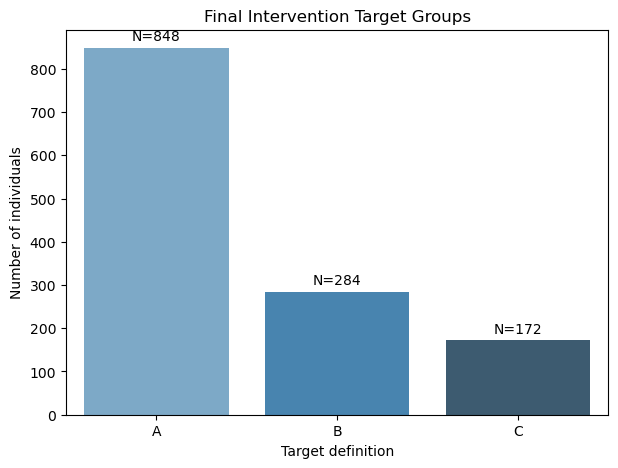

In [29]:
# ============================================================
# 25. FINAL TARGET BARPLOT
# ============================================================

target_plot_df = target_summary.copy()

plt.figure(figsize=(7, 5))

sns.barplot(
    data=target_plot_df,
    x="Target",
    y="N",
    palette="Blues_d"
)

plt.title("Final Intervention Target Groups")
plt.xlabel("Target definition")
plt.ylabel("Number of individuals")

for i, row in target_plot_df.iterrows():
    plt.text(
        i,
        row["N"] + 10,
        f'N={int(row["N"])}',
        ha="center",
        va="bottom"
    )

save_figure("figure_final_intervention_targets.png")

if SHOW_PLOTS:
    plt.show()
else:
    plt.close()


## 26. KEY RESULTS SUMMARY

In [30]:
# ============================================================
# 26. KEY RESULTS SUMMARY
# ============================================================

key_results = pd.DataFrame({
    "Quantity": [
        "Full BRFSS 2022 respondents",
        "Men aged 40--80 years",
        "Cancer-history modeling sample",
        "Self-reported prostate cancer history cases",
        "Observed prostate cancer history prevalence",
        "PSA/Nash-ready sample",
        "Observed PSA utilization rate in Nash-ready sample",
        "Mean predicted PSA propensity in Nash-ready sample",
        "Cancer-history model AUC",
        "Cancer-history model average precision",
        "Cancer-history model Brier score",
        "PSA model AUC",
        "PSA model average precision",
        "PSA model Brier score",
        "Conservative Nash screening rate",
        "Target A N",
        "Target B N",
        "Target C N"
    ],
    "Value": [
        len(df),
        len(men_40_80),
        int(df_model["had_prostate_cancer"].notna().sum()),
        int(df_model["had_prostate_cancer"].sum(skipna=True)),
        df_model["had_prostate_cancer"].mean(),
        len(nash_final_df),
        nash_final_df["had_psa"].mean(),
        nash_final_df["pred_psa_propensity"].mean(),
        cancer_results.loc[cancer_results["Model"] == final_cancer_model_name, "AUC"].iloc[0],
        cancer_results.loc[cancer_results["Model"] == final_cancer_model_name, "Average precision"].iloc[0],
        cancer_results.loc[cancer_results["Model"] == final_cancer_model_name, "Brier score"].iloc[0],
        psa_results.loc[psa_results["Model"] == final_psa_model_name, "AUC"].iloc[0],
        psa_results.loc[psa_results["Model"] == final_psa_model_name, "Average precision"].iloc[0],
        psa_results.loc[psa_results["Model"] == final_psa_model_name, "Brier score"].iloc[0],
        nash_final_df["eq_screen_conservative"].mean(),
        int(nash_final_df["target_A_no_psa_eq_screen"].sum()),
        int(nash_final_df["target_B_top_priority_no_psa"].sum()),
        int(nash_final_df["target_C_structural_underscreen"].sum())
    ]
})

display_table(key_results, "Key results summary", max_rows=30)

save_table(key_results, "table_key_results_summary.csv")



Key results summary
-------------------


,Quantity,Value
0,Full BRFSS 2022 respondents,445132.0000
1,Men aged 40--80 years,152936.0000
2,Cancer-history modeling sample,137141.0000
3,Self-reported prostate cancer history cases,1737.0000
4,Observed prostate cancer history prevalence,0.0127
5,PSA/Nash-ready sample,5809.0000
6,Observed PSA utilization rate in Nash-ready sa...,0.5641
7,Mean predicted PSA propensity in Nash-ready sa...,0.5625
8,Cancer-history model AUC,0.7945
9,Cancer-history model average precision,0.0353


In [31]:
# ============================================================
# 27. SAVE FINAL DATASET
# ============================================================

if SAVE_OUTPUTS:
    nash_final_df.to_csv(
        os.path.join(OUTPUT_DIR, "nash_final_prostate_psa_dataset.csv"),
        index=False
    )

final_dataset_summary = pd.DataFrame({
    "Item": [
        "Final dataset rows",
        "Final dataset columns",
        "Saved output folder",
        "Saved figure folder"
    ],
    "Value": [
        nash_final_df.shape[0],
        nash_final_df.shape[1],
        OUTPUT_DIR,
        FIGURE_DIR
    ]
})

display_table(final_dataset_summary, "Final dataset export summary")



Final dataset export summary
----------------------------


,Item,Value
0,Final dataset rows,5809
1,Final dataset columns,389
2,Saved output folder,outputs
3,Saved figure folder,figures
